In [1]:
import os
import json
import time
import zipfile
import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
from utilis import Utility, Data, Visualization, Score

# 2 - Load train and test data

The training maps are generated by $N_{\rm cosmo}$ cosmological models, each model contains $N_{\rm sys}$ realizations with different nuisance parameters. So the shape of the training maps kappa is $(N_{\rm cosmo}, N_{\rm sys}, 1424, 176)$. 

Each training map is associated with 5 parameters, so the shape of label is $(N_{\rm cosmo}, N_{\rm sys}, 5)$. The first two parameters are cosmological parameters $\Omega_m$ and $S_8$, while the rest three parameters are nuisance parameters that describe systematic effects and need to be marginalized in the data analysis (two of them describe baryonic effects and the last one describes photometric redshift uncertainties).

In [3]:
root_dir = os.getcwd()
print("Root directory is", root_dir)

Root directory is /Users/trungle/repo/Neurips2025_Weak_lensing


**Option 1: To quickly run through this starting kit:** You may set `USE_PUBLIC_DATASET = False` so that only a downsampled training data and test data will be loaded. In the downsampled training data, there are $N_{\rm cosmo}=3$ cosmological models and $N_{\rm sys}=30$ realizations of nuisance parameters. The downsampled test data contains $N_{\rm test}=3$ instances.

***

#### ⚠️ NOTE:
To make a valid submission and obtain a score on Codabench, **you will need to make your predictions using the entire test data set (4,000 instances). Use the Option 2 below to load the entire test data.**

***

**Option 2: To load the entire training data and test data:** Set `USE_PUBLIC_DATASET = True` and specify a path where you will save the downloaded public data from Codabench. In the entire training data, there are $N_{\rm cosmo}=101$ cosmological models and $N_{\rm sys}=256$ realizations of nuisance parameters. The entire test data contains $N_{\rm test}=4000$ instances.

In [4]:
USE_PUBLIC_DATASET = True

# USE_PUBLIC_DATASET = True
PUBLIC_DATA_DIR = './dataset'  # This is only required when you set USE_PUBLIC_DATASET = True

In [5]:
if not USE_PUBLIC_DATASET:                                         # Testing this startking kit with a tiny sample of the training data (3, 30, 1424, 176)
    DATA_DIR = os.path.join(root_dir, 'input_data/')
else:                                                              # Training your model with all training data (101, 256, 1424, 176)
    DATA_DIR = PUBLIC_DATA_DIR    

### Load the train and test data

In [6]:
# Initialize Data class object
data_obj = Data(data_dir=DATA_DIR, USE_PUBLIC_DATASET=USE_PUBLIC_DATASET)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

Loading WIDE12H_bin2_2arcmin_kappa.npy: 100%|██████████| 11/11 [00:28<00:00,  2.60s/it]
Loading WIDE12H_bin2_2arcmin_kappa_noisy_test.npy: 100%|██████████| 40/40 [00:02<00:00, 13.96it/s]


In [ ]:
# import numpy as np
# import os

# # Đường dẫn tới thư mục chứa các chunk noisy và file label gốc
# chunk_dir = '/Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise'
# label_path = '/Users/viethuy/Working_space/Neurips/Neurips_lensing/label.npy'

# # Lấy danh sách các file chunk noisy, đảm bảo đúng thứ tự
# chunk_files = sorted([f for f in os.listdir(chunk_dir) if f.startswith('kappa_noisy_chunk_') and f.endswith('.npy')])

# # Nạp toàn bộ label
# labels = np.load(label_path)

# start = 0
# for chunk_file in chunk_files:
#     chunk_path = os.path.join(chunk_dir, chunk_file)
#     noisy_chunk = np.load(chunk_path)
#     num_samples = noisy_chunk.shape[0]
#     labels_chunk = labels[start:start+num_samples]
    
#     # Lưu file nhãn tương ứng
#     label_chunk_name = chunk_file.replace('kappa_noisy_chunk_', 'label_chunk_')
#     label_chunk_path = os.path.join(chunk_dir, label_chunk_name)
#     np.save(label_chunk_path, labels_chunk)
    
#     print(f"Saved {label_chunk_path} with shape {labels_chunk.shape}")
#     start += num_samples

Saved /Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise/label_chunk_0.npy with shape (11, 256, 5)
Saved /Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise/label_chunk_1.npy with shape (10, 256, 5)
Saved /Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise/label_chunk_2.npy with shape (10, 256, 5)
Saved /Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise/label_chunk_3.npy with shape (10, 256, 5)
Saved /Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise/label_chunk_4.npy with shape (10, 256, 5)
Saved /Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise/label_chunk_5.npy with shape (10, 256, 5)
Saved /Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise/label_chunk_6.npy with shape (10, 256, 5)
Saved /Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise/label_chunk_7.npy with shape (10, 256, 5)
Saved /Users/viethuy/Working_space/Neurips/Neuri

In [7]:
Ncosmo = data_obj.Ncosmo
Nsys = data_obj.Nsys

print(f'There are {Ncosmo} cosmological models, each has {Nsys} realizations of nuisance parameters in the training data.')

There are 101 cosmological models, each has 256 realizations of nuisance parameters in the training data.


In [8]:
print(f'Shape of the training data = {data_obj.kappa.shape}')
print(f'Shape of the mask = {data_obj.mask.shape}')
print(f'Shape of the training label = {data_obj.label.shape}')
print(f'Shape of the test data = {data_obj.kappa_test.shape}')

Shape of the training data = (101, 256, 1424, 176)
Shape of the mask = (1424, 176)
Shape of the training label = (101, 256, 5)
Shape of the test data = (4000, 1424, 176)


#### ⚠️ NOTE:
- The original training images are *noiseless* (without any pixel-level noise).
- The original test images is *noisy* (pixel-level noise with galaxy number density $n_g = 30~\text{arcmin}^{-2}$ and pixel size $=2$ arcmin has been added).

- **You will have to add pixel-level noise to the training data through the helper function** `Utility.add_noise`.
    
For example:
```python
    noisy_kappa = Utility.add_noise(data=data_obj.kappa.astype(np.float64), 
                                    mask=data_obj.mask, 
                                    ng=data_obj.ng, 
                                    pixel_size=data_obj.pixelsize_arcmin)
```

The shape of `noisy_kappa` will be the same as the shape of `data_obj.kappa`.

In [ ]:
# import os
# import numpy as np

# # Directory to save chunks
# save_dir = '/Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa'
# os.makedirs(save_dir, exist_ok=True)

# # Number of chunks you want
# num_chunks = 10  # Change this as needed

# # Split kappa along the first axis (Ncosmo)
# chunks = np.array_split(data_obj.kappa, num_chunks, axis=0)

# for idx, chunk in enumerate(chunks):
#     chunk_path = os.path.join(save_dir, f'kappa_chunk_{idx}.npy')
#     np.save(chunk_path, chunk)
#     print(f'Saved {chunk_path}, shape: {chunk.shape}')

In [ ]:
# import os
# import numpy as np

# # Directory to save noisy chunks
# save_dir = '/Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise'
# os.makedirs(save_dir, exist_ok=True)

# # Number of chunks
# num_chunks = 10  # Adjust as needed

# np.random.seed(113)  # For reproducibility

# chunks = np.array_split(data_obj.kappa, num_chunks, axis=0)

# for idx, chunk in enumerate(chunks):
#     noisy_chunk = Utility.add_noise(
#         data=chunk.astype(np.float64),
#         mask=data_obj.mask,
#         ng=data_obj.ng,
#         pixel_size=data_obj.pixelsize_arcmin
#     )
#     chunk_path = os.path.join(save_dir, f'kappa_noisy_chunk_{idx}.npy')
#     np.save(chunk_path, noisy_chunk)
#     print(f'Saved {chunk_path}, shape: {noisy_chunk.shape}')

In [ ]:
# # Add the pixel-level noise to the training set (note that this may take some time and large memory)

# np.random.seed(113)  # Fix the random seed for reproducible results
# noisy_kappa = Utility.add_noise(data=data_obj.kappa.astype(np.float64), 
#                                 mask=data_obj.mask, 
#                                 ng=data_obj.ng, 
#                                 pixel_size=data_obj.pixelsize_arcmin)

In [9]:
import os
import numpy as np

def load_all_noisy_chunks(folder_path):
    # Lấy danh sách file .npy và sắp xếp theo tên
    files = sorted([f for f in os.listdir(folder_path) if f.startswith('kappa_noisy_chunk_') and f.endswith('.npy')])
    chunks = []
    for f in files:
        chunk = np.load(os.path.join(folder_path, f))
        chunks.append(chunk)
    return np.concatenate(chunks, axis=0)

# Sử dụng:
noisy_kappa = load_all_noisy_chunks('/Users/trungle/repo/Neurips2025_Weak_lensing/dataset/chunk_kappa_noise')
print('noisy_kappa shape:', noisy_kappa.shape)

: 

In [ ]:
print(f'Shape of the noised data {noisy_kappa.shape}')

#### ⚠️ NOTE:

If you want to split your own training/validation sets to evaluate your model, we recommend splitting the original training data along `axis = 1` (the 256 realizations of nuisance parameters). This will ensure that there are no intrinsic correlations between the training and validation sets.

In [17]:
import numpy as np
import os

def load_single_chunk(chunk_idx, chunk_dir):
    """
    Nạp 1 chunk noisy_kappa và label tương ứng.
    Args:
        chunk_idx (int): chỉ số chunk muốn nạp.
        chunk_dir (str): đường dẫn tới thư mục chứa các chunk.
    Returns:
        noisy_kappa (np.ndarray), label (np.ndarray)
    """
    noisy_path = os.path.join(chunk_dir, f'kappa_noisy_chunk_{chunk_idx}.npy')
    label_path = os.path.join(chunk_dir, f'label_chunk_{chunk_idx}.npy')
    noisy_kappa = np.load(noisy_path)
    label = np.load(label_path)
    return noisy_kappa, label

# Ví dụ sử dụng:
chunk_dir = '/Users/viethuy/Working_space/Neurips/Neurips_lensing/chunk_kappa_noise'
chunk_idx = 0  # thay đổi nếu muốn nạp chunk khác
noisy_kappa, label = load_single_chunk(chunk_idx, chunk_dir)
print('noisy_kappa shape:', noisy_kappa.shape)
print('label shape:', label.shape)

noisy_kappa shape: (11, 256, 1424, 176)
label shape: (11, 256, 5)


In [18]:
# Split the data into training and validation sets

NP_idx = np.arange(Nsys)  # The indices of Nsys nuisance parameter realizations
split_fraction = 0.2      # Set the fraction of data you want to split (between 0 and 1)
seed = 5566               # Define your random seed for reproducible results

train_NP_idx, val_NP_idx = train_test_split(NP_idx, test_size=split_fraction,
                                            random_state=seed)

noisy_kappa_train = noisy_kappa[:, train_NP_idx]      # shape = (Ncosmo, len(train_NP_idx), 1424, 176)
label_train = label[:, train_NP_idx]         # shape = (Ncosmo, len(train_NP_idx), 5)
noisy_kappa_val = noisy_kappa[:, val_NP_idx]          # shape = (Ncosmo, len(val_NP_idx), 1424, 176)
label_val = label[:, val_NP_idx]             # shape = (Ncosmo, len(val_NP_idx), 5)

Ntrain = label_train.shape[0]*label_train.shape[1]
Nval = label_val.shape[0]*label_val.shape[1]

In [ ]:
# # Split the data into training and validation sets

# NP_idx = np.arange(Nsys)  # The indices of Nsys nuisance parameter realizations
# split_fraction = 0.2      # Set the fraction of data you want to split (between 0 and 1)
# seed = 5566               # Define your random seed for reproducible results

# train_NP_idx, val_NP_idx = train_test_split(NP_idx, test_size=split_fraction,
#                                             random_state=seed)

# noisy_kappa_train = noisy_kappa[:, train_NP_idx]      # shape = (Ncosmo, len(train_NP_idx), 1424, 176)
# label_train = data_obj.label[:, train_NP_idx]         # shape = (Ncosmo, len(train_NP_idx), 5)
# noisy_kappa_val = noisy_kappa[:, val_NP_idx]          # shape = (Ncosmo, len(val_NP_idx), 1424, 176)
# label_val = data_obj.label[:, val_NP_idx]             # shape = (Ncosmo, len(val_NP_idx), 5)

# Ntrain = label_train.shape[0]*label_train.shape[1]
# Nval = label_val.shape[0]*label_val.shape[1]

In [19]:
print(f'Shape of the split training data = {noisy_kappa_train.shape}')
print(f'Shape of the split validation data = {noisy_kappa_val.shape}')

print(f'Shape of the split training labels = {label_train.shape}')
print(f'Shape of the split validation labels = {label_val.shape}')

Shape of the split training data = (11, 204, 1424, 176)
Shape of the split validation data = (11, 52, 1424, 176)
Shape of the split training labels = (11, 204, 5)
Shape of the split validation labels = (11, 52, 5)


In [ ]:
# Save the split data and labels for future usage

Utility.save_np(data_dir=DATA_DIR, file_name="noisy_kappa_train.npy",data=noisy_kappa_train)
Utility.save_np(data_dir=DATA_DIR, file_name="label_train.npy",data=label_train)
Utility.save_np(data_dir=DATA_DIR, file_name="noisy_kappa_val.npy",data=noisy_kappa_val)
Utility.save_np(data_dir=DATA_DIR, file_name="label_val.npy",data=label_val)

In [ ]:
# # Load the saved split data (if you saved it at DATA_DIR before)

# noisy_kappa_train = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_train.npy")
# label_train = Utility.load_np(data_dir=DATA_DIR, file_name="label_train.npy")
# noisy_kappa_val = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_val.npy")
# label_val = Utility.load_np(data_dir=DATA_DIR, file_name="label_val.npy")

# Ntrain = label_train.shape[0]*label_train.shape[1]
# Nval = label_val.shape[0]*label_val.shape[1]

In [20]:
# Reshape the data for CNN
X_train = noisy_kappa_train.reshape(Ntrain, *data_obj.shape)
X_val = noisy_kappa_val.reshape(Nval, *data_obj.shape)

# Here, we ignore the nuisance parameters and only keep the 2 cosmological parameters
y_train = label_train.reshape(Ntrain, 5)[:, :2]
y_val = label_val.reshape(Nval, 5)[:, :2]

In [21]:
print(f'Shape of the split training data = {X_train.shape}')
print(f'Shape of the split validation data = {X_val.shape}')

print(f'Shape of the split training labels = {y_train.shape}')
print(f'Shape of the split validation labels = {y_val.shape}')

Shape of the split training data = (2244, 1424, 176)
Shape of the split validation data = (572, 1424, 176)
Shape of the split training labels = (2244, 2)
Shape of the split validation labels = (572, 2)


# 3 - Visualization

### 2D training maps

survey mask: a binary map that shows which parts of the sky are observed (yellow) and which areas are blocked (purple)

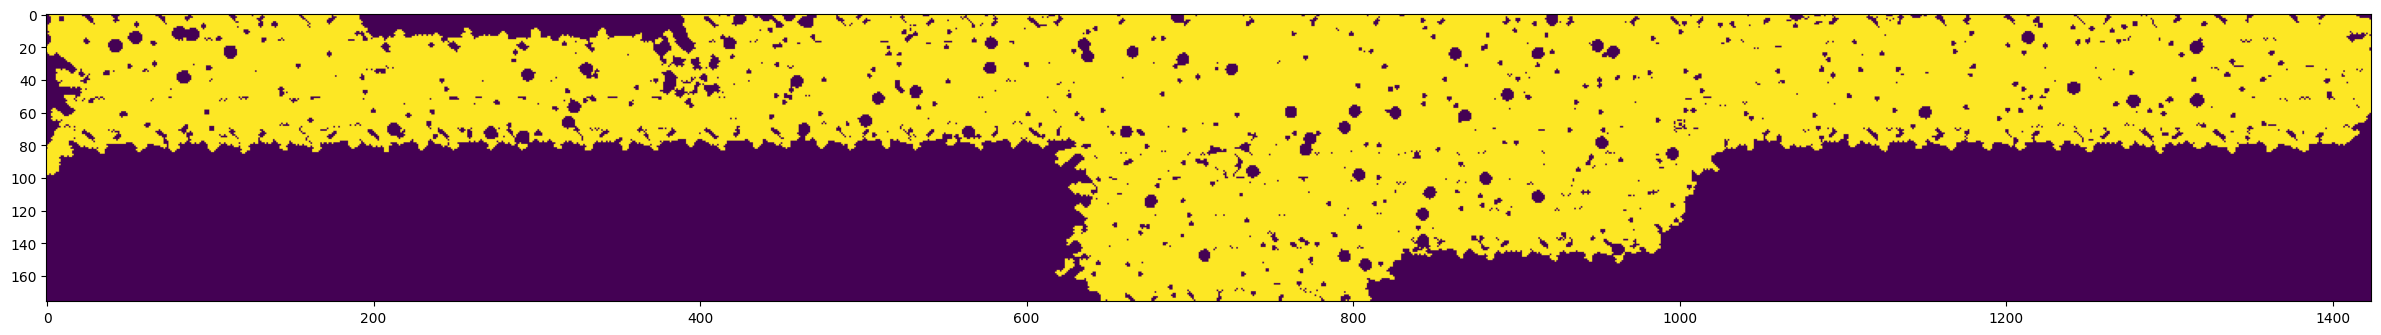

In [22]:
# mask
Visualization.plot_mask(mask=data_obj.mask)

noiseless training convergence map: The convergence maps show the projected matter density (including dark matter and ordinary matter) in the simulated universe, under the Born approximation. On large scales, we can see the matter forms web-like structures (cosmic web) in the universe. The dense regions in these maps, called dark matter halos, are the sites where galaxies form and reside.

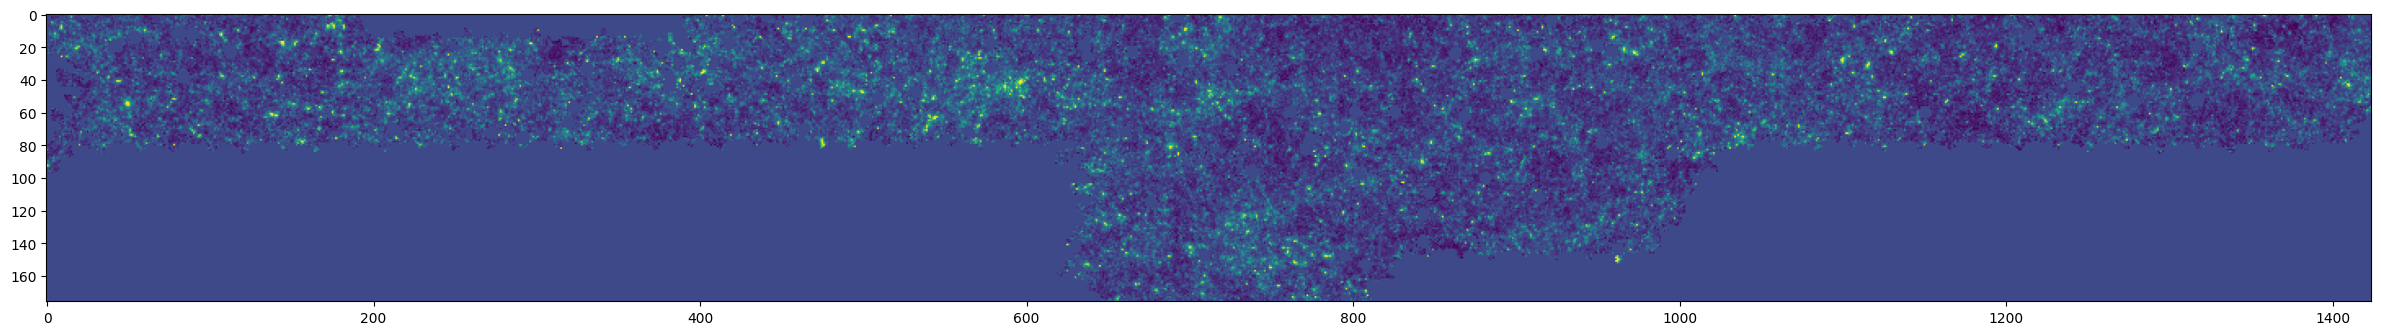

In [23]:
# noiseless training convergence map
Visualization.plot_noiseless_training_convergence_map(kappa=data_obj.kappa)

noisy training convergence map: We add Gaussian noise to the data. This mimics the observed data. During training the noise can be added on the fly with different realizations.

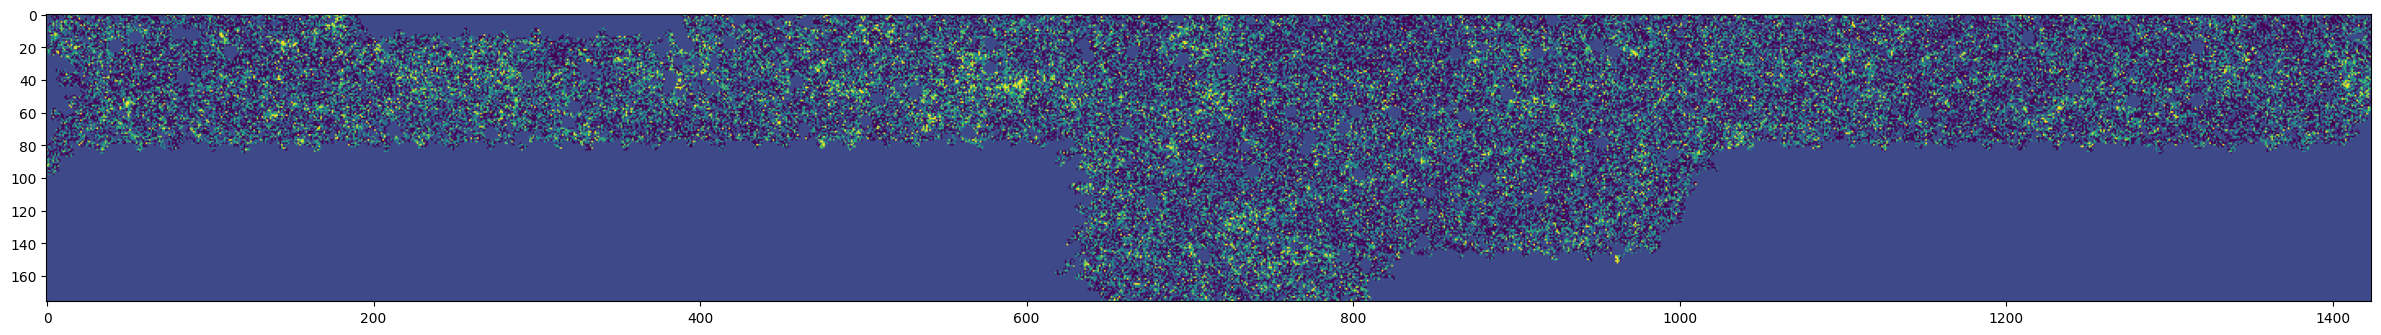

In [24]:
# noisy training convergence map
Visualization.plot_noisy_training_convergence_map(kappa=data_obj.kappa,
                                                  mask=data_obj.mask,
                                                  pixelsize_arcmin=data_obj.pixelsize_arcmin,
                                                  ng=data_obj.ng)

### Distribution of physical parameters

Distribution of cosmological parameters $\Omega_m$ and $S_8$. The density increases towards fiducial cosmology. Note that this distribution introduces a prior in the analysis. The test data cosmology follows the same distribution as the training data.

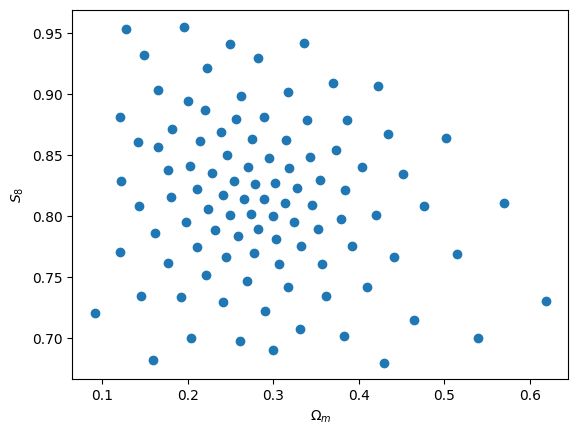

In [25]:
Visualization.plot_cosmological_parameters_OmegaM_S8(label=data_obj.viz_label)

Distribution of baryonic physics parameters. These are nuisance parameters and should be marginalized in the analysis. They follow a uniform distribution within the prior range $T_{\mathrm{AGN}} \in [7.2, 8.5]$, $f_0 \in [0, 0.0265]$

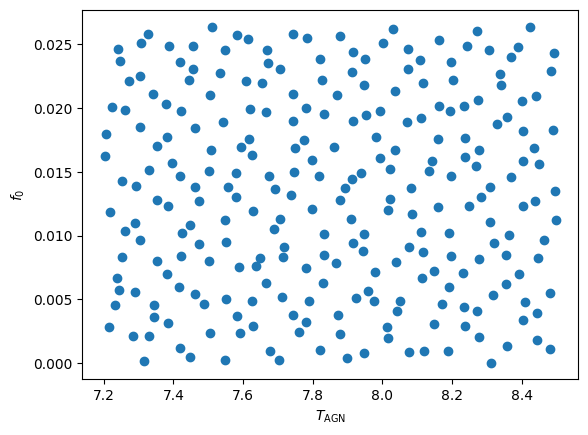

In [26]:
Visualization.plot_baryonic_physics_parameters(label=data_obj.viz_label)

Distribution of photometric redshift uncertainty parameters. This is a nuisance parameter and should be marginalized in the analysis. It follows a Gaussian distribution with mean 0 and std 0.022

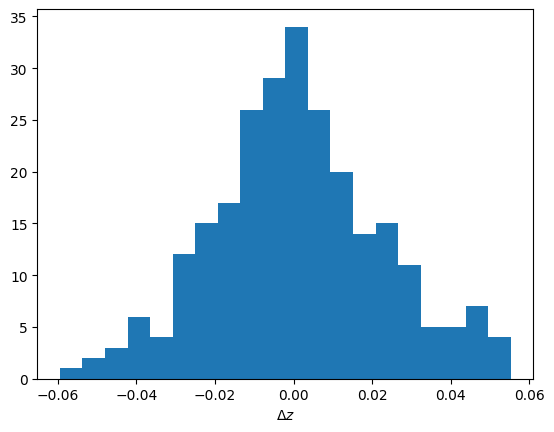

In [27]:
Visualization.plot_photometric_redshift_uncertainty_parameters(label=data_obj.viz_label)

# 4 - Training

In this notebook, we do not fit any predefined summary statistics to the data and perform MCMC. Instead, we estimate the uncertainties directly using the CNN. This is achieved by optimizing a KL divergence objective function using neural network predictions during training. For each 2D map, the CNN will predict its cosmological parameters $(\hat{\Omega}_m, \hat{S}_8)$ and the standard deviations of the joint Gaussian posterior distribution $(\hat{\sigma}_{\Omega_m}, \hat{\sigma}_{S_8})$.

The loss funciton here is a KL divergence objective function defined by
$$
\text{KL Loss}= \frac{1}{N} \sum_i^{N}\left\{\frac{\left(\hat{\Omega}_{m, i}-\Omega_{m, i}^{\text {truth }}\right)^2}{\hat{\sigma}_{\Omega_m, i}^2}+\frac{\left(\hat{S}_{8, i}-S_{8, i}^{\text {truth }}\right)^2}{\hat{\sigma}_{S_8, i}^2}+\log \left(\hat{\sigma}_{\Omega_m, i}^2\right)+\log \left(\hat{\sigma}_{S_8, i}^2\right)\right\}~.
$$

In [29]:
# Define your path for saving the trained model
MODEL_SAVE_PATH = os.path.join(root_dir, "Phase1_starting_kit_CNN_Direct_baseline.pth")

class Config:
    IMG_HEIGHT = data_obj.shape[0]
    IMG_WIDTH = data_obj.shape[1]
    
    # Parameters to predict (Omega_m, S_8, sigma_Omega_m, sigma_S_8)
    NUM_TARGETS = 4

    # Training hyperparameters
    BATCH_SIZE = 64
    EPOCHS = 15
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 1e-4   # L2 regularization to prevent overfitting
    
    DEVICE = "mps" if torch.mps.is_available() else "cpu"
    MODEL_SAVE_PATH = MODEL_SAVE_PATH

In [30]:
# Simple CNN architecture for parameter estimation

class Simple_CNN(nn.Module):
    def __init__(self, height, width, num_targets):
        super(Simple_CNN, self).__init__()
        # Convolutional layers
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self._feature_size = self._get_conv_output_size(height, width)
        
        # Fully connected layers (regressor head)
        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._feature_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_targets)
        )

    def _get_conv_output_size(self, height, width):
        dummy_input = torch.zeros(1, 1, height, width)
        output = self.conv_stack(dummy_input)
        return int(np.prod(output.size()))

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.fc_stack(x)
        means = x[:, :2]
        log_sigmas = x[:, 2:]    # Predict log(σ) to ensure positivity
        sigmas = torch.exp(log_sigmas)
        return means, sigmas     # Note that means and sigmas here have to be rescaled properly due to standardization

In [31]:
def KL_div_posterior_loss(pred_means, pred_sigmas, truths):
    """
    A KL divergence loss function that directly optimizes the score function
    
    Inputs:
    - pred_means:   2D tensor (batch_size, 2)
    - pred_sigmas:  2D tensor (batch_size, 2) 
    - truths:       2D tensor (batch_size, 2)
    """
    
    residuals_sq = (pred_means - truths)**2  
    
    loss_terms = residuals_sq / (pred_sigmas**2)
    loss_sum = torch.sum(loss_terms, dim=1)
    
    log_sigma_terms = torch.sum(torch.log(pred_sigmas**2), dim=1)
    loss = torch.mean(loss_sum + log_sigma_terms)
    
    return loss

In [32]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    """Trains the model for one epoch."""
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Training")
    for X, y in pbar:
        X, y = X.to(device), y.to(device)

        # Forward pass
        pred_means, pred_sigmas= model(X)
        loss = loss_fn(pred_means, pred_sigmas, y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, loss_fn, device):
    """Validates the model on the validation/test set."""
    model.eval()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Validating")
    with torch.no_grad():
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            pred_means, pred_sigmas = model(X)
            total_loss += loss_fn(pred_means, pred_sigmas, y).item()
            
    return total_loss / len(dataloader)

In [33]:
class CosmologyDataset(Dataset):
    """
    Custom PyTorch Dataset
    """
    
    def __init__(self, data, labels=None,
                 transform=None,
                 label_transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
        self.label_transform = label_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].astype(np.float32)   # Convert from float16 to float32
        if self.transform:
            image = self.transform(image) 
        if self.labels is not None:
            label = self.labels[idx].astype(np.float32)
            label = torch.from_numpy(label)
            if self.label_transform:
                label = self.label_transform(label)
            return image, label
        else:
            return image

In [34]:
# Compute the means and stds of the training images (for standardizing the data)

means = np.mean(X_train, dtype=np.float32)
stds = np.std(X_train, dtype=np.float32)

In [35]:
# Image standardization
from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor(),     
    transforms.Normalize(mean=[means], std=[stds]),   
])
print(f"Image stats (from train set): Mean={means}, Std={stds}")

# Label standardization
label_scaler = StandardScaler()
y_train_scaled = label_scaler.fit_transform(y_train)
y_val_scaled = label_scaler.transform(y_val)
print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

Image stats (from train set): Mean=-0.00014450734306592494, Std=0.02063327468931675
Label stats (from train set): Mean=[0.32273636 0.82877394], Std=[0.11488696 0.06162615]


In [36]:
# Load the configuration
config = Config()
print(f"Using device: {config.DEVICE}")

# Create Datasets and DataLoaders
train_dataset = CosmologyDataset(
    data=X_train, 
    labels=y_train_scaled,
    transform=transform
)
val_dataset = CosmologyDataset(
    data=X_val, 
    labels=y_val_scaled,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

Using device: mps


In [37]:
# Initialize the CNN model
model = Simple_CNN(config.IMG_HEIGHT,
                    config.IMG_WIDTH,
                    config.NUM_TARGETS).to(config.DEVICE)

Set `USE_PRETRAINED_MODEL = False` if you want to train a new model.\
Set `USE_PRETRAINED_MODEL = True` if you want to load a pretrained model.

In [38]:
USE_PRETRAINED_MODEL = False
# USE_PRETRAINED_MODEL = True

In [39]:
if not USE_PRETRAINED_MODEL:  
    # Train the model
    loss_fn = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(),
                                lr=config.LEARNING_RATE,
                                weight_decay=config.WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer,
                                  mode='min',
                                  factor=0.5,
                                  patience=5)
    # Training Loop
    best_val_loss = float('inf')
    start_time = time.time()
    for epoch in range(config.EPOCHS):
        train_loss = train_epoch(model, train_loader, KL_div_posterior_loss, optimizer, config.DEVICE)
        val_loss = validate_epoch(model, val_loader, KL_div_posterior_loss, config.DEVICE)
    
        scheduler.step(val_loss)    
        print(f"Epoch {epoch+1}/{config.EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        
        # Save the best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
            print(f"  -> New best model saved to {config.MODEL_SAVE_PATH}")

    end_time = time.time()
    print(f"\nTraining finished in {(end_time - start_time)/60:.2f} minutes.")
    
    model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True)) # Directly load the best model

else:
    # Check if the pretrained model exists
    if os.path.exists(config.MODEL_SAVE_PATH):
        # If the pretrained model exists, load the model
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))

    else:
        # If the pretrained model doesn't exist, show the warning message
        warning_msg = f"The path of pretrained model doesn't exist"
        warnings.warn(warning_msg)

Validating: 100%|██████████| 9/9 [00:01<00:00,  7.92it/s]


Epoch 1/15 | Train Loss: 4.143460 | Val Loss: 2.151695
  -> New best model saved to /Users/viethuy/Working_space/Neurips/OG/Cosmology_Challenge/Phase1_starting_kit_CNN_Direct_baseline.pth


Validating: 100%|██████████| 9/9 [00:00<00:00, 10.61it/s]


Epoch 2/15 | Train Loss: 2.127407 | Val Loss: 1.979195
  -> New best model saved to /Users/viethuy/Working_space/Neurips/OG/Cosmology_Challenge/Phase1_starting_kit_CNN_Direct_baseline.pth


Validating: 100%|██████████| 9/9 [00:01<00:00,  8.70it/s]


...

Epoch 13/15 | Train Loss: 0.342160 | Val Loss: 0.769169


Validating: 100%|██████████| 9/9 [00:00<00:00,  9.97it/s]


Epoch 14/15 | Train Loss: -0.044507 | Val Loss: -0.231544
  -> New best model saved to /Users/viethuy/Working_space/Neurips/OG/Cosmology_Challenge/Phase1_starting_kit_CNN_Direct_baseline.pth


Validating: 100%|██████████| 9/9 [00:00<00:00, 10.04it/s]


Epoch 15/15 | Train Loss: -0.206724 | Val Loss: 3.399694

Training finished in 2.28 minutes.


# 5 - Inference on the validation set

In [40]:
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
with torch.no_grad():
    for X, _ in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean_val = np.concatenate(means_pred_list, axis=0)
mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std

Validating: 100%|██████████| 9/9 [00:00<00:00, 10.82it/s]


In [41]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean_val - errorbar_val < 0
errorbar_val[negative_mask] = mean_val[negative_mask]

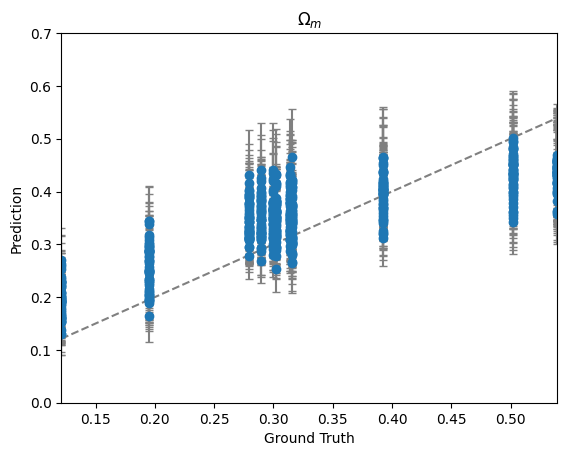

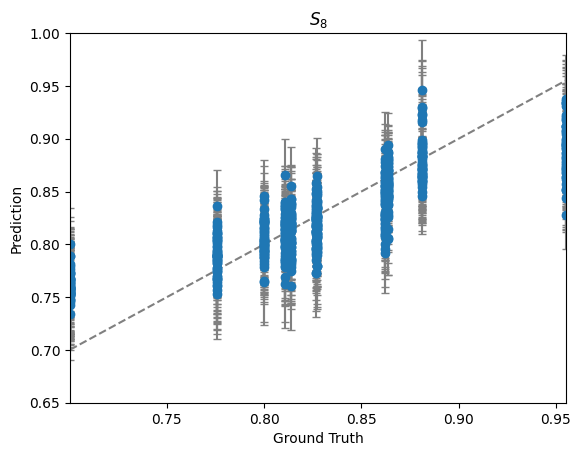

In [42]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels

plt.errorbar(y_val[:,0], mean_val[:,0], yerr=errorbar_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,0]), sorted(y_val[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,0]), np.max(y_val[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(y_val[:,1], mean_val[:,1], yerr=errorbar_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,1]), sorted(y_val[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,1]), np.max(y_val[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [43]:
validation_score = Score._score_phase1(
    true_cosmo=y_val,
    infer_cosmo=mean_val,
    errorbar=errorbar_val
)
print('averaged score:', np.mean(validation_score))
print('averaged error bar:', np.mean(errorbar_val, 0))

averaged score: 3.6862280333435717
averaged error bar: [0.06242608 0.0355755 ]


# 6 - Phase one inference

### Estimate the summary statistics $\boldsymbol{d}$ for all test data

In [44]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

In [45]:
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(test_loader, total=len(test_loader), desc="Inference on the test set")
with torch.no_grad():
    for X in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean = np.concatenate(means_pred_list, axis=0)
mean = label_scaler.inverse_transform(mean)          # inverse transform

errorbar = np.concatenate(sigmas_pred_list, axis=0)
errorbar = errorbar*label_scaler.var_**0.5           # rescale by the training label std

Inference on the test set: 100%|██████████| 63/63 [00:09<00:00,  6.32it/s]


In [46]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean - errorbar < 0
errorbar[negative_mask] = mean[negative_mask]

#### ⚠️ NOTE:
- `mean`: a 2D array containing the point estimates of 2 cosmological parameters $\hat{\Omega}_m$ and $\hat{S}_8$.
- `errorbar`: a 2D array containing the one-standard deviation uncertainties of 2 cosmological parameters $\hat{\sigma}_{\Omega_m}$ and  $\hat{\sigma}_{S_8}$.
 
The shapes of `mean`, and `errorbar` must be $(N_{\rm test}, 2)$.

***

# 7 - (Optional) Prepare submission for Codabench

***

This section will save the model predictions `mean` and `errorbar` (both are 2D arrays with shape `(4000, 2)`, where `4000` is the number of test instances and `2` is the number of our parameters of interest) as a dictionary in a JSON file `result.json`. Then it will compress `result.json` into a zip file that can be directly submitted to Codabench.

***

In [47]:
data = {"means": mean.tolist(), "errorbars": errorbar.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

Submission ZIP saved at: submissions/Submission_25-09-16-22-53.zip
